1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

2. Load Dataset

In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

3. Data Exploration

In [3]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

4. Missing Value Handling

In [4]:
# Fill Age with median

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

# Verify

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


5. Encoding Categorical Variables

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df["Embarked"] = le.fit_transform(df["Embarked"])

print(df[["Sex","Embarked"]].head())

   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


6. Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age","Fare"]] = scaler.fit_transform(
    df[["Age","Fare"]]
)

print(df[["Age","Fare"]].head())

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


7. Outlier Detection

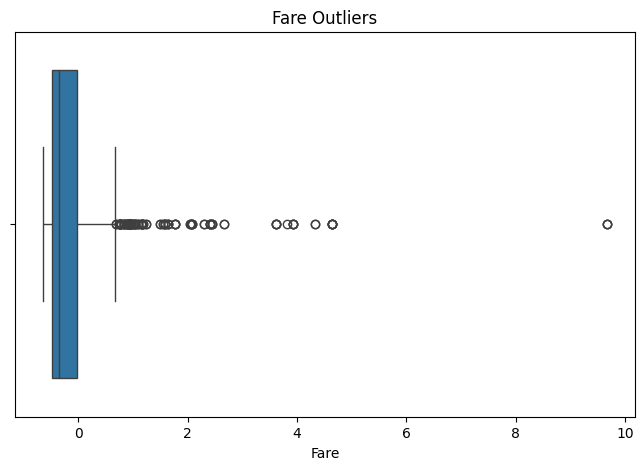

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

8. Outlier Removal

In [8]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df["Fare"] >= lower) &
    (df["Fare"] <= upper)
]

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (891, 11)
Clean Shape: (775, 11)


9. Save Cleaned Dataset

In [9]:
df_clean.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Conclusion

The Titanic dataset was successfully cleaned and preprocessed for machine learning.

The following preprocessing steps were performed:

1. Missing values in Age were filled using the median.
2. Missing values in Embarked were filled using the mode.
3. Cabin column was removed due to a large number of missing values.
4. Categorical variables were encoded using Label Encoding.
5. Numerical features were standardized using StandardScaler.
6. Outliers were detected using boxplots and removed using the IQR method.

The final cleaned dataset contains 775 records and is ready for machine learning model development.